<a href="https://colab.research.google.com/github/kumargauravindia/AI-Penetration-Testing-Sponge-DoS-Attack/blob/main/Sponge_DDoS_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install transformers psutil torch

In [ ]:
# ============================================================
# Sponge Attack Demonstration - Google Colab
# Normal vs Sponge-style Input
# ============================================================

# !pip -q install transformers psutil torch

import time
import psutil
import torch
from transformers import pipeline

# Small model suitable for Colab CPU
MODEL = "distilgpt2"

generator = pipeline(
    "text-generation",
    model=MODEL,
    device=-1
)

normal_prompt = """
Explain artificial intelligence in simple terms.
"""

sponge_prompt = """
Explain artificial intelligence in extremely detailed form.
Discuss machine learning, deep learning, neural networks,
transformers, attention mechanisms, training, inference,
optimization, datasets, embeddings, tokenization, model
architecture, security, adversarial attacks, deployment,
monitoring and evaluation.

For every topic provide detailed explanations, examples,
edge cases, historical context and technical discussion.
Continue the explanation extensively.
"""

def run_test(name, prompt, max_new_tokens):

    process = psutil.Process()

    cpu_before = psutil.cpu_percent(interval=0.2)
    mem_before = process.memory_info().rss / (1024 ** 2)

    start = time.perf_counter()

    result = generator(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        return_full_text=False
    )

    elapsed = time.perf_counter() - start

    cpu_after = psutil.cpu_percent(interval=0.2)
    mem_after = process.memory_info().rss / (1024 ** 2)

    output = result[0]["generated_text"]

    print("\n==============================")
    print(name)
    print("==============================")
    print("Time       :", round(elapsed, 2), "seconds")
    print("Characters :", len(output))
    print("CPU before :", cpu_before, "%")
    print("CPU after  :", cpu_after, "%")
    print("RAM before :", round(mem_before, 1), "MB")
    print("RAM after  :", round(mem_after, 1), "MB")

    return {
        "name": name,
        "time": elapsed,
        "characters": len(output),
        "cpu": cpu_after,
        "ram": mem_after
    }


normal = run_test(
    "WITHOUT SPONGE",
    normal_prompt,
    max_new_tokens=50
)

sponge = run_test(
    "WITH SPONGE",
    sponge_prompt,
    max_new_tokens=500
)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



WITHOUT SPONGE
Time       : 1.43 seconds
Characters : 50
CPU before : 0.0 %
CPU after  : 0.0 %
RAM before : 665.5 MB
RAM after  : 973.7 MB


[transformers] Both `max_new_tokens` (=500) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



WITH SPONGE
Time       : 15.83 seconds
Characters : 2389
CPU before : 0.0 %
CPU after  : 5.1 %
RAM before : 973.7 MB
RAM after  : 975.2 MB


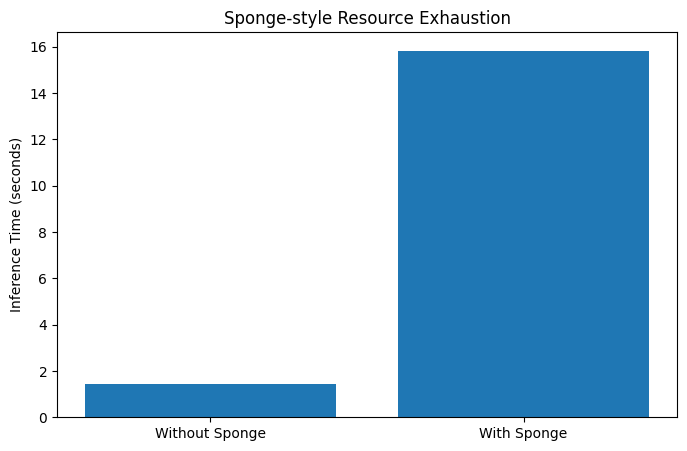

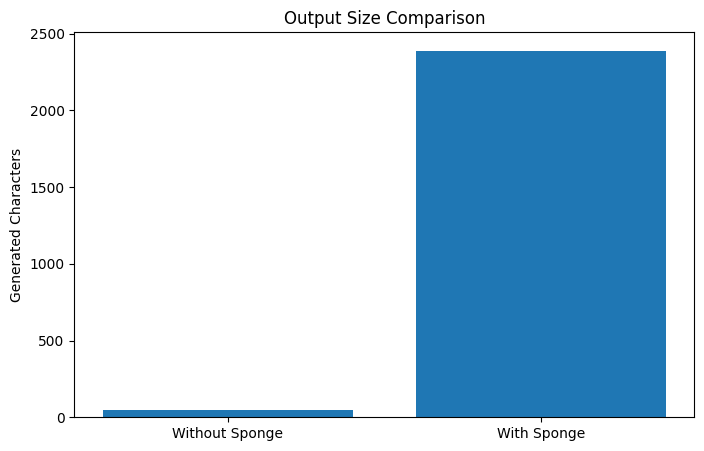

In [ ]:
import matplotlib.pyplot as plt

names = ["Without Sponge", "With Sponge"]

times = [
    normal["time"],
    sponge["time"]
]

characters = [
    normal["characters"],
    sponge["characters"]
]

plt.figure(figsize=(8,5))
plt.bar(names, times)
plt.ylabel("Inference Time (seconds)")
plt.title("Sponge-style Resource Exhaustion")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(names, characters)
plt.ylabel("Generated Characters")
plt.title("Output Size Comparison")
plt.show()